# 1. Load Dynamo & Data

In [4]:
import numba
numba.set_num_threads(1)

In [5]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')

import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import anndata as ad
import harmonypy as hp

Using already downloaded Arial font from: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf
Registered custom font as: Arial


In [6]:
def process_adata(path):
    adata = dyn.read(path)
    
    # Drop duplicate gene symbols and modify for Dynamo format
    symbols = adata.var["gene_symbols"].astype(str).values
    unique_symbols, index_inverse = np.unique(symbols, return_inverse=True)
    
    # Summing matrix: original genes x unique genes
    # This is a sparse matrix of 1s that tells the computer which rows to sum
    row = np.arange(len(symbols))
    col = index_inverse
    data = np.ones(len(symbols))
    S = sparse.csr_matrix((data, (row, col)), shape=(len(symbols), len(unique_symbols)))

    # Take the first occurrence of each symbol to keep metadata (like chromosome)
    _, first_indices = np.unique(symbols, return_index=True)
    var_unique = adata.var.iloc[first_indices].copy()
    var_unique.index = symbols[first_indices]
    var_unique.index.name = None
    
    # cells x genes) @ (genes x unique genes)
    new_X = adata.X @ S
    
    new_adata = ad.AnnData(X=new_X, obs=adata.obs.copy(), var=var_unique)
    
    for layer in ['spliced', 'unspliced']:
        if layer in adata.layers:
            new_adata.layers[layer] = adata.layers[layer] @ S
            
    print(new_adata)
    return new_adata

files = ['SRX21172619.h5ad', 'SRX23456399.h5ad', 'SRX21788827.h5ad', 'SRX21788830.h5ad']
adata_list = [process_adata(f) for f in files]
adata = ad.concat(adata_list, join='inner', label='condition', 
                  keys=['Control', 'NMDA 36hrs', 'NMDA 72hrs', 'NMDA 96hrs'])
print("Concatenated adata:", adata) #17.7s

AnnData object with n_obs × n_vars = 16064 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 29896 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 27622 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 28182 × 25404
    obs: 'gene_coun

# 2. Preprocessing

In [7]:
preprocessor = dyn.pp.Preprocessor()
preprocessor.regress_out_kwargs["obs_keys"] = []
preprocessor.preprocess_adata_monocle(adata)
dyn.pp.normalize_cell_expr_by_size_factors(adata)
adata
# 30s

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 2123 outlier cells
|-----------> filtered out 10901 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> [Preprocessor-monocle] completed [22.3089s]
|-----> Set <adata.X> to normalized data


AnnData object with n_obs × n_vars = 99641 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id', 'condition', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'Size_Factor', 'initial_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'ntr'
    var: 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'score', 'log_cv', 'frac', 'use_for_pca', 'ntr'
    uns: 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean'
    obsm: 'X_pca'
    layers: 'spliced', 'unspliced', 'X_spliced', 'X_unspliced'

In [8]:
# Use Harmony to reduce batch effects
adata.obsm['X_pca_harmony'] = hp.run_harmony(adata.obsm['X_pca'], adata.obs, 'condition').Z_corr

2026-03-08 00:09:07,780 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-03-08 00:09:07,780 - harmonypy - INFO -   Parameters:
2026-03-08 00:09:07,780 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-08 00:09:07,781 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-08 00:09:07,781 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-08 00:09:07,781 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-08 00:09:07,781 - harmonypy - INFO -     nclust: 100
2026-03-08 00:09:07,781 - harmonypy - INFO -     block_size: 0.05
2026-03-08 00:09:07,782 - harmonypy - INFO -     lamb: [1. 1. 1. 1.]
2026-03-08 00:09:07,782 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-03-08 00:09:07,782 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-08 00:09:07,782 - harmonypy - INFO -     verbose: True
2026-03-08 00:09:07,783 - harmonypy - INFO -     random_state: 0
2026-03-08 00:09:07,783 - harmonypy - INFO -   Data: 30 PCs × 99641 cells
2026-03-08 00:09:07,783 - harm

In [9]:
sc.pp.neighbors(adata, 
                n_neighbors=10, # Large number of neighbors give more global features
                n_pcs=30,
                use_rep="X_pca_harmony")
# 10s

In [10]:
sc.tl.leiden(adata,
             resolution=0.5, # Larger values give more clusters
             flavor="igraph",
             n_iterations=2,
             directed=False,
             random_state=28,
)

In [11]:
sc.tl.umap(adata,
           spread = 1,
           min_dist=0.5) # The effective minimum distance between embedded points
                         # Smaller values will result in a more clustered/clumped embedding
# 30s

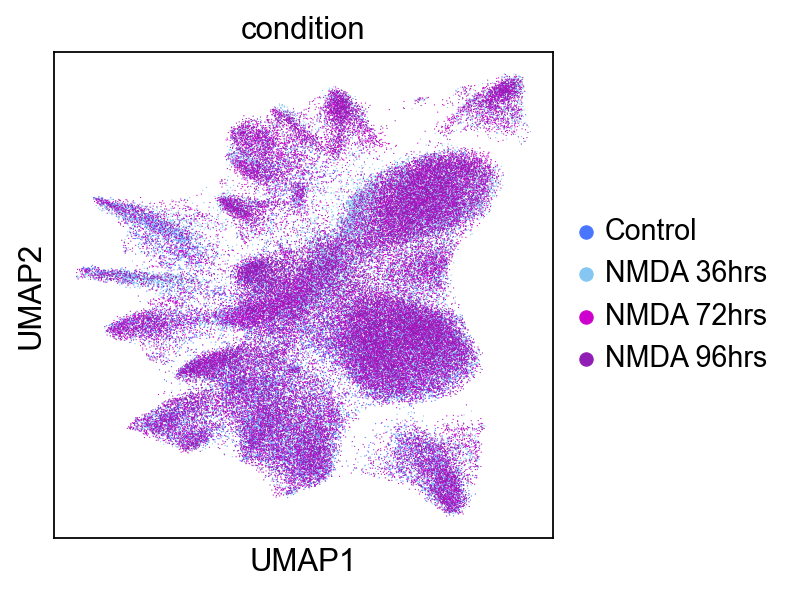

In [12]:
# Check if batch effect is removed
sc.pl.umap(adata, color="condition")

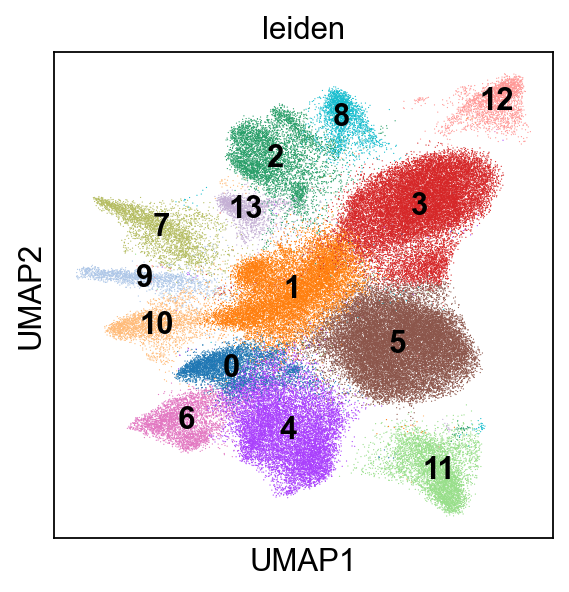

In [13]:
# Coarse cell clusters
sc.pl.umap(adata, 
           color="leiden", 
           legend_loc="on data")
# 10 Clusters

# 3. Cell type annotations

In [14]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
DEG = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
DEG.head(30)
# 1m 30s

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,slc6a9,mt-atp6,prph2a,rho,syt1a,grin1b,rbpms2a,grna,opn1mw2,stra6,slc1a2b,SLC4A5,opn1sw1,opn1sw2
1,syt1a,mt-co3,slc24a2,si:ch211-113d22.2,slc6a1b,slc12a5b,islr2,ctsc,prph2a,rgrb,rhbg,tnr,ly6pge,prph2a
2,grin1a,mt-co2,thrb,rom1b,sv2a,zfhx4,si:dkey-7j14.5,mrc1b,slc24a2,tyrp1b,nfasca,pcdh8,prph2a,clul1
3,nrxn1a,mt-nd4,hexb,pde6gb,slc32a1,nova2,grin1a,lgals3bp.1,clul1,pmelb,aqp1a.1,ENSDARG00000116725,fat1b,opn6b
4,slc32a1,si:dkey-151g10.6,six7,gnat1,gad2,aplp1,rbpms2b,cd74b,six7,msnb,col18a1a,mdka,opn6b,slc24a2
5,pax6b,mt-nd1,clul1,gnb1a,pclob,mt-co1,igfbp5b,ctsba,prph2b,rpe65a,zgc:165604,vtnb,spock3,spock3
6,pax6a,rplp1,si:busm1-57f23.1,pde6b,grin1a,mt-cyb,atp2b3b,apoc1,atp6ap1lb,rbp5,mdka,atp1b1a,clul1,prph2b
7,gpm6aa,mt-co1,camk2d1,gnb1b,gpm6aa,lrit1a,elavl3,lgals9l1,opn6b,tm6sf2b,selenop,slc12a2,slc24a2,arr3b
8,sv2a,mt-nd2,SAMD4B,cnga1a,stx1b,mt-co2,rtn1a,cd68,kera,pmela,pik3ip1,syt1a,tmem237a,tmem237a
9,cspg5a,mt-cyb,SLC38A5,gngt1,atp1a3a,rs1a,gpm6ab,psap,SAMD4B,ambp,id1,atp2b4,prph2b,ly6pge


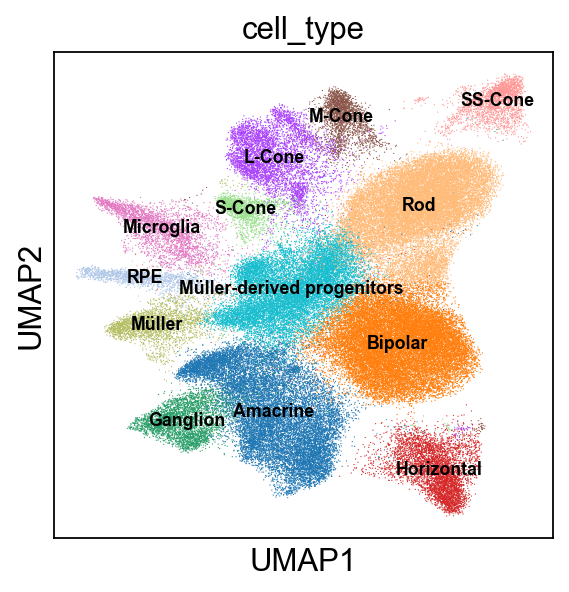

In [18]:
cluster_annotation = {
    "0": "Amacrine",
    "1": "Müller-derived progenitors",
    "2": "L-Cone",
    "3": "Rod",
    "4": "Amacrine",
    "5": "Bipolar",
    "6": "Ganglion",
    "7": "Microglia",
    "8": "M-Cone",
    "9": "RPE",
    "10": "Müller",
    "11": "Horizontal",
    "12": "SS-Cone",
    "13": "S-Cone"
}

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_annotation)

sc.pl.umap(adata, color="cell_type", legend_loc="on data", legend_fontsize=8)

In [19]:
# Save results
adata.write('results/adata_celltype_annotated.h5ad')

In [20]:
# Save results by condition
conditions = adata.obs['condition'].unique()
adata_subsets = {cond: adata[adata.obs['condition'] == cond].copy() for cond in conditions}

In [21]:
adata_subsets['Control'].write('results/adata_cont_celltype_annotated.h5ad')
adata_subsets['NMDA 36hrs'].write('results/adata_nmda_36_celltype_annotated.h5ad')
adata_subsets['NMDA 72hrs'].write('results/adata_nmda_72_celltype_annotated.h5ad')
adata_subsets['NMDA 96hrs'].write('results/adata_nmda_96_celltype_annotated.h5ad')